In [2]:
import pandas as pd

# Definir la ruta de tu archivo Parquet limpio en Google Drive
file_path_processed = '/content/drive/MyDrive/Archivo de 1GB - loans/loan_processed.parquet'

# Cargar el archivo Parquet procesado
print("Cargando el archivo Parquet procesado...")
df_processed = pd.read_parquet(file_path_processed)

Cargando el archivo Parquet procesado...


Loading optimized column subset from Parquet...
Mapping target variable statuses to binary (0 and 1)...
Downsampling dataset from 1,306,387 to 500,000 rows for memory safety...
Optimizing feature data types...
Preparing LightGBM Dataset...
Training LightGBM baseline model...


/tmp/ipykernel_3812/718210875.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


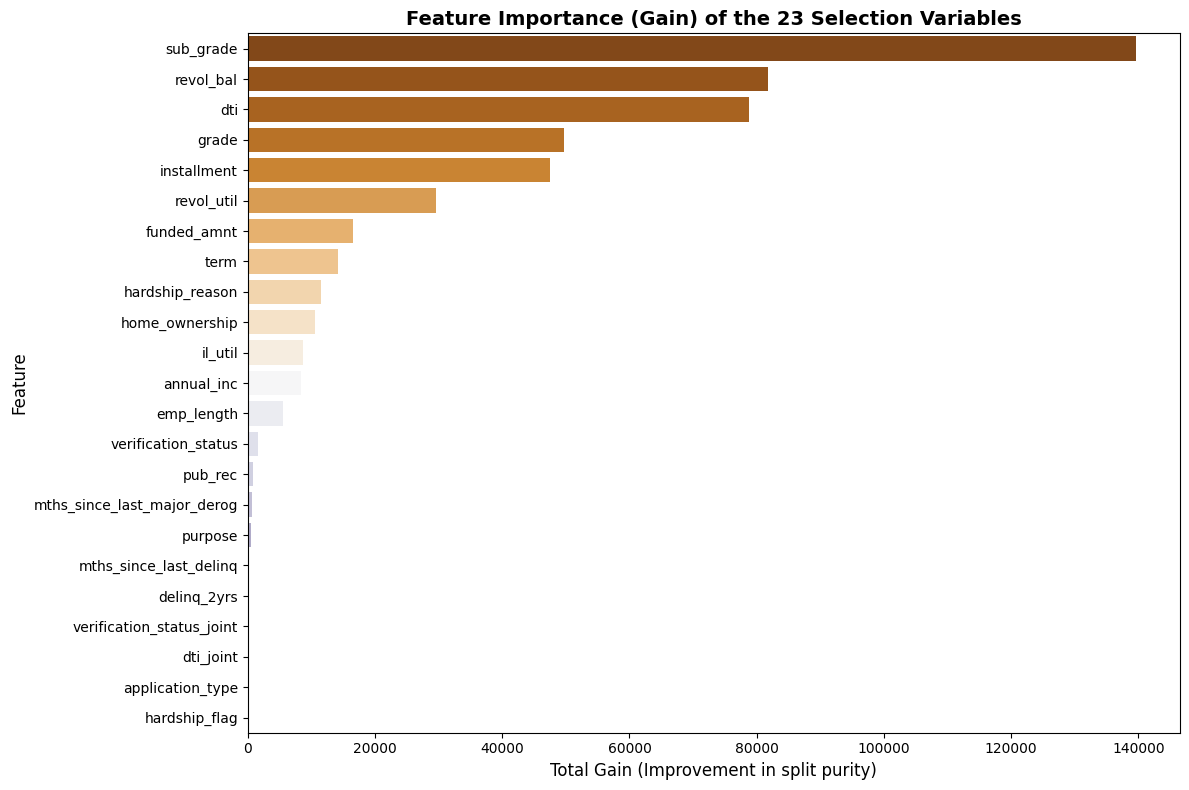

In [3]:
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# ==========================================
# 1. Configuration & File Paths
# ==========================================
file_path_parquet = '/content/drive/MyDrive/Archivo de 1GB - loans/loan_processed.parquet'
target_col = 'loan_status'

features = [
    'funded_amnt', 'term', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'mths_since_last_delinq', 'pub_rec',
    'revol_bal', 'revol_util', 'application_type', 'dti_joint',
    'verification_status_joint', 'mths_since_last_major_derog', 'il_util',
    'hardship_flag', 'hardship_reason'
]

# Loading ONLY the target and our 23 features to save massive amounts of RAM
columns_to_load = features + [target_col]

# ==========================================
# 2. Load and Clean Data
# ==========================================
print("Loading optimized column subset from Parquet...")
df = pd.read_parquet(file_path_parquet, columns=columns_to_load)

# Drop rows where target is null
df = df.dropna(subset=[target_col])

# Map target text labels to binary integers (0 = Good, 1 = Bad)
# Note: 'Current' and other ongoing statuses map to NaN and get dropped.
status_mapping = {
    'Fully Paid': 0,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Charged Off': 1
}

print("Mapping target variable statuses to binary (0 and 1)...")
df[target_col] = df[target_col].map(status_mapping)

# Drop any unmapped statuses (like 'Current', 'In Grace Period', etc.)
df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].astype('int8')

# ==========================================
# 3. Memory Optimization & Sampling
# ==========================================
# Downsample to 500,000 rows (plenty for a highly accurate feature importance calculation)
if len(df) > 500000:
    print(f"Downsampling dataset from {len(df):,} to 500,000 rows for memory safety...")
    df = df.sample(n=500000, random_state=42)

# Split features and target
X = df[features].copy()
y = df[target_col].copy()

# Delete original dataframe and force garbage collection to free up RAM
del df
gc.collect()

print("Optimizing feature data types...")
# Downcast float types
for col in X.select_dtypes(include=['float64']).columns:
    X[col] = X[col].astype('float32')

# Downcast integer types
for col in X.select_dtypes(include=['int64']).columns:
    X[col] = X[col].astype('int32')

# Explicitly cast text/object columns to pandas Categorical
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    X[col] = X[col].astype('category')

# ==========================================
# 4. LightGBM Setup and Training
# ==========================================
print("Preparing LightGBM Dataset...")
train_data = lgb.Dataset(X, label=y, categorical_feature=categorical_cols)

# Set fast, standard baseline training parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1,
    'seed': 42
}

print("Training LightGBM baseline model...")
model = lgb.train(params, train_data, num_boost_round=100)

# ==========================================
# 5. Extract and Plot Feature Importance
# ==========================================
# Extracting importance based on 'gain' (contribution to reducing impurity/loss)
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values(by='importance', ascending=False)

# Render the plot
plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance',
    y='feature',
    data=importance_df,
    palette='PuOr'
)
plt.title('Feature Importance (Gain) of the 23 Selection Variables', fontsize=14, fontweight='bold')
plt.xlabel('Total Gain (Improvement in split purity)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

Loading optimized column subset from Parquet...
Mapping target variable statuses to binary (0 and 1)...
Downsampling dataset from 1,306,387 to 500,000 rows for memory safety...
Optimizing feature data types...
Preparing LightGBM Dataset...
Training final, leakage-free LightGBM baseline model...


/tmp/ipykernel_3812/397078916.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


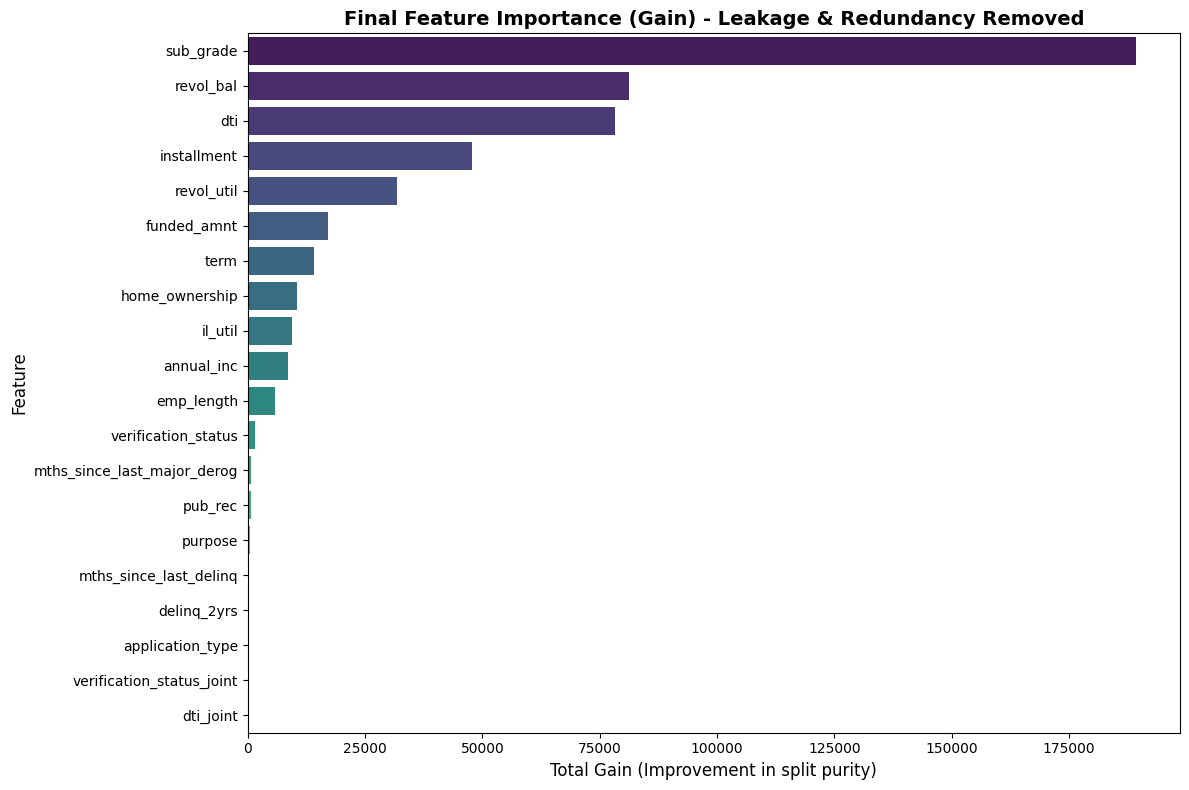

In [4]:
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# ==========================================
# 1. Configuration & File Paths
# ==========================================
file_path_parquet = '/content/drive/MyDrive/Archivo de 1GB - loans/loan_processed.parquet'
target_col = 'loan_status'

# We have dropped 'grade' (redundant with sub_grade)
# and the hardship variables (preventing target leakage)
features = [
    'funded_amnt', 'term', 'installment', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'mths_since_last_delinq', 'pub_rec',
    'revol_bal', 'revol_util', 'application_type', 'dti_joint',
    'verification_status_joint', 'mths_since_last_major_derog', 'il_util'
]

# Loading ONLY the target and our 20 final features to keep RAM usage low
columns_to_load = features + [target_col]

# ==========================================
# 2. Load and Clean Data
# ==========================================
print("Loading optimized column subset from Parquet...")
df = pd.read_parquet(file_path_parquet, columns=columns_to_load)

# Drop rows where target is null
df = df.dropna(subset=[target_col])

# Map target text labels to binary integers (0 = Good, 1 = Bad)
# Note: 'Current' and other ongoing statuses map to NaN and get dropped.
status_mapping = {
    'Fully Paid': 0,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Charged Off': 1
}

print("Mapping target variable statuses to binary (0 and 1)...")
df[target_col] = df[target_col].map(status_mapping)

# Drop any unmapped statuses (like 'Current', 'In Grace Period', etc.)
df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].astype('int8')

# ==========================================
# 3. Memory Optimization & Sampling
# ==========================================
# Downsample to 500,000 rows for quick, RAM-safe calculation
if len(df) > 500000:
    print(f"Downsampling dataset from {len(df):,} to 500,000 rows for memory safety...")
    df = df.sample(n=500000, random_state=42)

# Split features and target
X = df[features].copy()
y = df[target_col].copy()

# Delete original dataframe and force garbage collection to free up RAM
del df
gc.collect()

print("Optimizing feature data types...")
# Downcast float types
for col in X.select_dtypes(include=['float64']).columns:
    X[col] = X[col].astype('float32')

# Downcast integer types
for col in X.select_dtypes(include=['int64']).columns:
    X[col] = X[col].astype('int32')

# Explicitly cast text/object columns to pandas Categorical
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    X[col] = X[col].astype('category')

# ==========================================
# 4. LightGBM Setup and Training
# ==========================================
print("Preparing LightGBM Dataset...")
train_data = lgb.Dataset(X, label=y, categorical_feature=categorical_cols)

# Set fast, standard baseline training parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1,
    'seed': 42
}

print("Training final, leakage-free LightGBM baseline model...")
model = lgb.train(params, train_data, num_boost_round=100)

# ==========================================
# 5. Extract and Plot Feature Importance
# ==========================================
# Extracting importance based on 'gain' (contribution to reducing impurity/loss)
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values(by='importance', ascending=False)

# Render the plot
plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance',
    y='feature',
    data=importance_df,
    palette='viridis'
)
plt.title('Final Feature Importance (Gain) - Leakage & Redundancy Removed', fontsize=14, fontweight='bold')
plt.xlabel('Total Gain (Improvement in split purity)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

Loading only the 4 key variables...


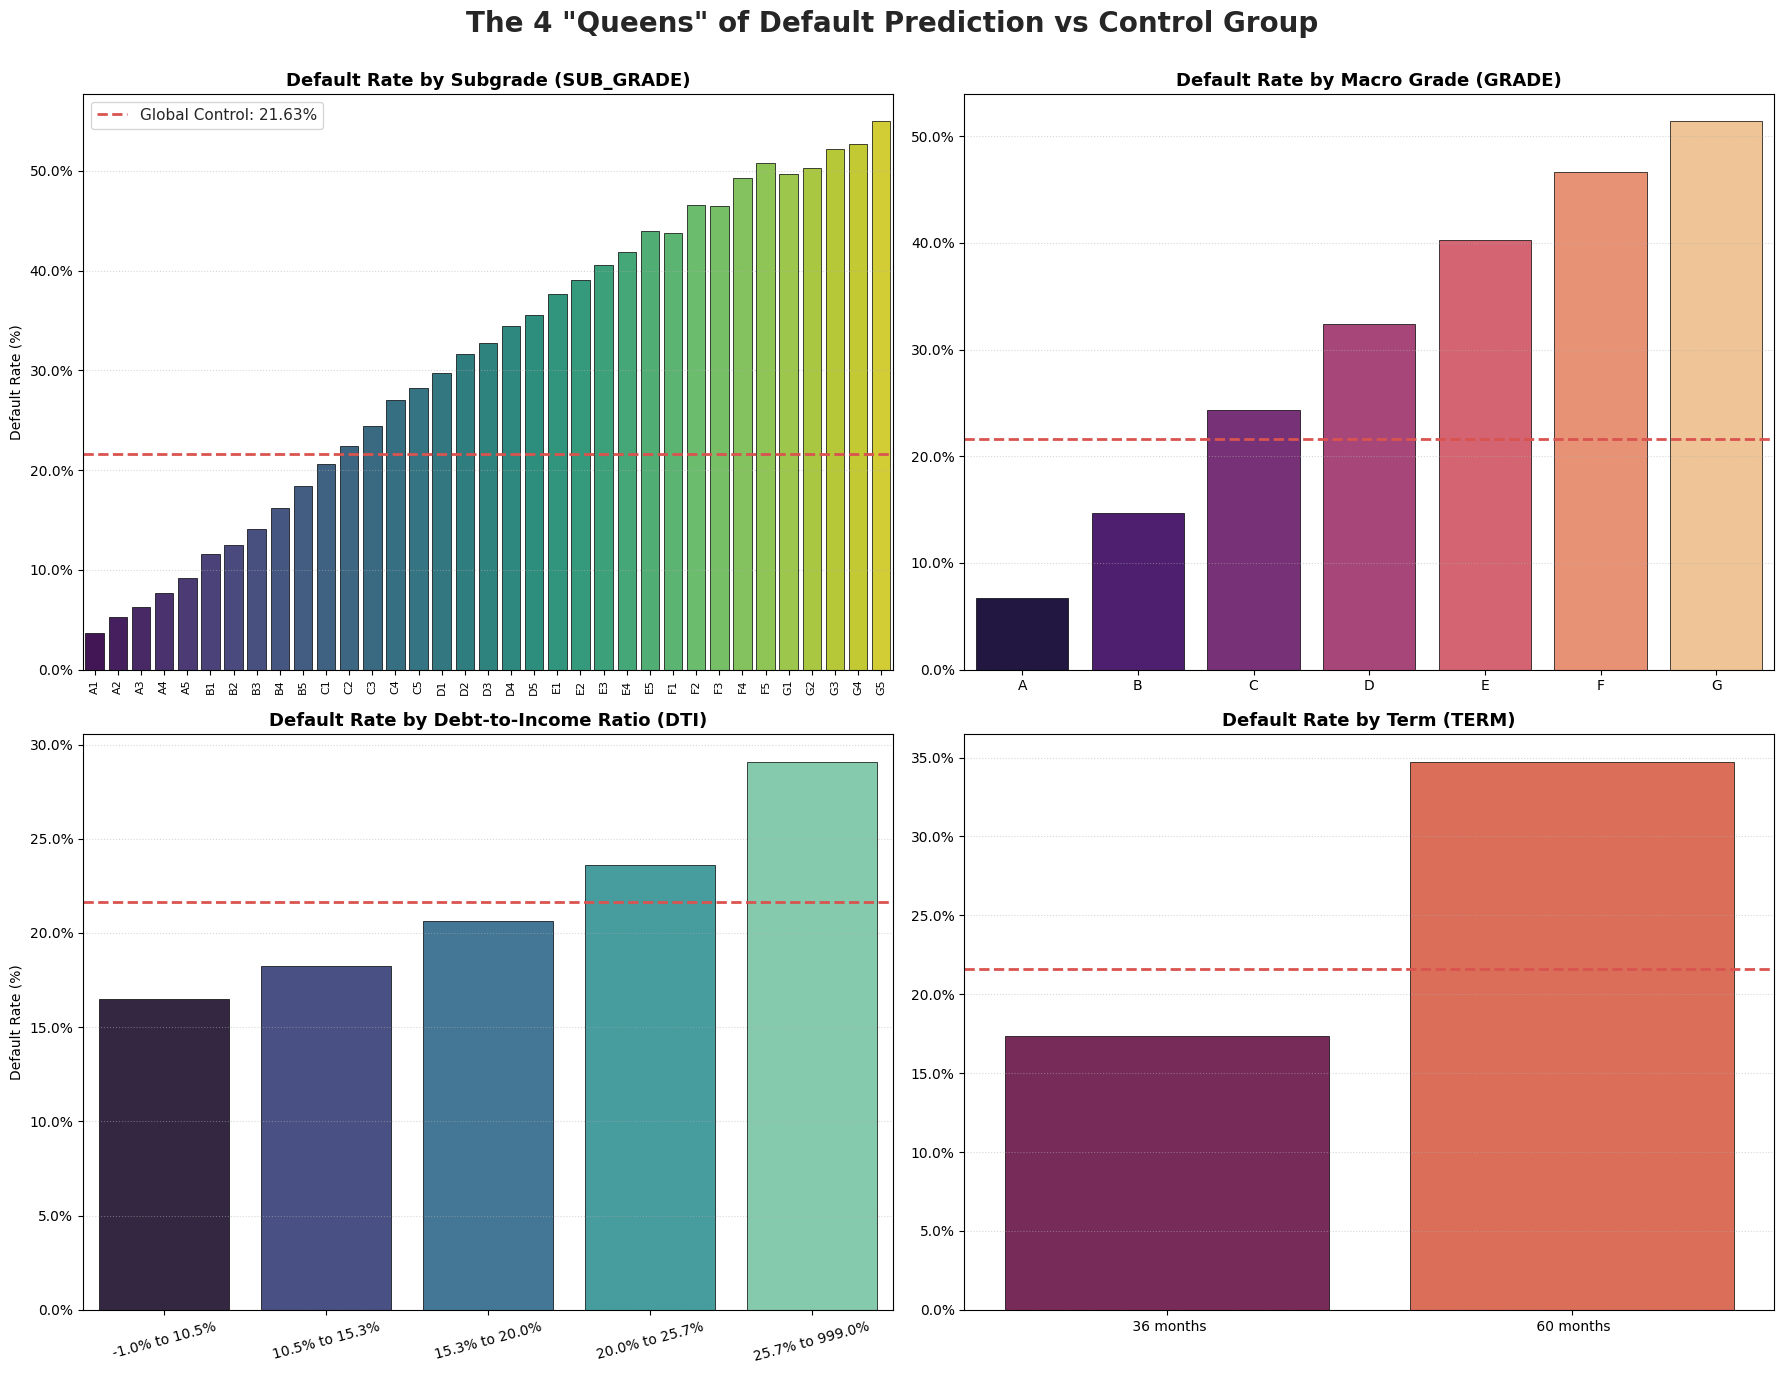

7154

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# --- 1. OPTIMIZED DATA LOADING ---
file_path_processed = '/content/drive/MyDrive/Archivo de 1GB - loans/loan_processed.parquet'
TARGET_VAR = 'loan_status'
the_4_queens = ['sub_grade', 'grade', 'dti', 'term']

columns_to_load = the_4_queens + [TARGET_VAR]

print("Loading only the 4 key variables...")
df_raw = pd.read_parquet(file_path_processed, columns=columns_to_load)

# --- 2. TARGET PREPARATION ---
df_clean = df_raw.dropna(subset=[TARGET_VAR]).copy()
del df_raw
gc.collect()

if df_clean[TARGET_VAR].dtype == 'object' or isinstance(df_clean[TARGET_VAR].dtype, pd.CategoricalDtype):
    status_mapping = {
        'Fully Paid': 0.0, 'Does not meet the credit policy. Status:Fully Paid': 0.0,
        'Charged Off': 1.0, 'Default': 1.0, 'Does not meet the credit policy. Status:Charged Off': 1.0,
        'Late (31-120 days)': 1.0, 'Late (16-30 days)': 1.0
    }
    df_clean['target'] = df_clean[TARGET_VAR].map(status_mapping)
    df_clean = df_clean.dropna(subset=['target'])
else:
    df_clean['target'] = pd.to_numeric(df_clean[TARGET_VAR], errors='coerce')
    df_clean = df_clean.dropna(subset=['target'])

TARGET_VAR_PROCESSED = 'target'
global_rate = float(df_clean[TARGET_VAR_PROCESSED].mean())

# --- 3. PROFESSIONAL DTI CLEANING ---
# Force conversion to numeric. Non-numeric values will convert to NaN and be dropped.
df_clean['dti'] = pd.to_numeric(df_clean['dti'], errors='coerce')

# --- 4. 2x2 CANVAS CONFIGURATION ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

control_color = '#d9534f'  # Professional red
sns.set_theme(style="whitegrid")

# ==========================================
# PANEL 1: SUB_GRADE
# ==========================================
ax = axes[0]
temp1 = df_clean[['sub_grade', TARGET_VAR_PROCESSED]].dropna()
res1 = temp1.groupby('sub_grade', observed=False)[TARGET_VAR_PROCESSED].mean().reset_index()
res1 = res1.sort_values(by='sub_grade')

sns.barplot(
    data=res1, x='sub_grade', y=TARGET_VAR_PROCESSED, hue='sub_grade',
    ax=ax, palette='viridis', edgecolor='black', linewidth=0.5, legend=False
)
ax.axhline(global_rate, color=control_color, linestyle='--', linewidth=2, label=f'Global Control: {global_rate:.2%}')
ax.set_title('Default Rate by Subgrade (SUB_GRADE)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.legend(loc='upper left')

# ==========================================
# PANEL 2: GRADE
# ==========================================
ax = axes[1]
temp2 = df_clean[['grade', TARGET_VAR_PROCESSED]].dropna()
res2 = temp2.groupby('grade', observed=False)[TARGET_VAR_PROCESSED].mean().reset_index()
res2 = res2.sort_values(by='grade')

sns.barplot(
    data=res2, x='grade', y=TARGET_VAR_PROCESSED, hue='grade',
    ax=ax, palette='magma', edgecolor='black', linewidth=0.5, legend=False
)
ax.axhline(global_rate, color=control_color, linestyle='--', linewidth=2)
ax.set_title('Default Rate by Macro Grade (GRADE)', fontsize=13, fontweight='bold')

# ==========================================
# PANEL 3: DTI (Corrected with prior numeric conversion!)
# ==========================================
ax = axes[2]
temp3 = df_clean[['dti', TARGET_VAR_PROCESSED]].dropna()

# Create 5 bins based on the real numeric distribution
temp3['Group'] = pd.qcut(temp3['dti'], q=5, duplicates='drop')
res3 = temp3.groupby('Group', observed=False)[TARGET_VAR_PROCESSED].mean().reset_index()

# Sort intervals
res3['lower_limit'] = res3['Group'].apply(lambda x: x.left)
res3 = res3.sort_values(by='lower_limit')
res3['Label'] = res3['Group'].apply(lambda x: f"{x.left:.1f}% to {x.right:.1f}%")

sns.barplot(
    data=res3, x='Label', y=TARGET_VAR_PROCESSED, hue='Label',
    ax=ax, palette='mako', edgecolor='black', linewidth=0.5, legend=False
)
ax.axhline(global_rate, color=control_color, linestyle='--', linewidth=2)
ax.set_title('Default Rate by Debt-to-Income Ratio (DTI)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=15)

# ==========================================
# PANEL 4: TERM
# ==========================================
ax = axes[3]
temp4 = df_clean[['term', TARGET_VAR_PROCESSED]].dropna()
res4 = temp4.groupby('term', observed=False)[TARGET_VAR_PROCESSED].mean().reset_index()

sns.barplot(
    data=res4, x='term', y=TARGET_VAR_PROCESSED, hue='term',
    ax=ax, palette='rocket', edgecolor='black', linewidth=0.5, legend=False
)
ax.axhline(global_rate, color=control_color, linestyle='--', linewidth=2)
ax.set_title('Default Rate by Term (TERM)', fontsize=13, fontweight='bold')

# --- 5. GLOBAL AESTHETICS ---
for idx, ax in enumerate(axes):
    ax.set_xlabel('')
    ax.set_ylabel('Default Rate (%)' if idx % 2 == 0 else '')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.suptitle('The 4 "Queens" of Default Prediction vs Control Group', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save to Google Drive
plt.savefig('/content/drive/MyDrive/Archivo de 1GB - loans/the_4_queens_default.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean memory at the end
del temp1, temp2, temp3, temp4, res1, res2, res3, res4
gc.collect()

Loading data...


/tmp/ipykernel_3812/464589269.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(res['sub_grade'], rotation=90)


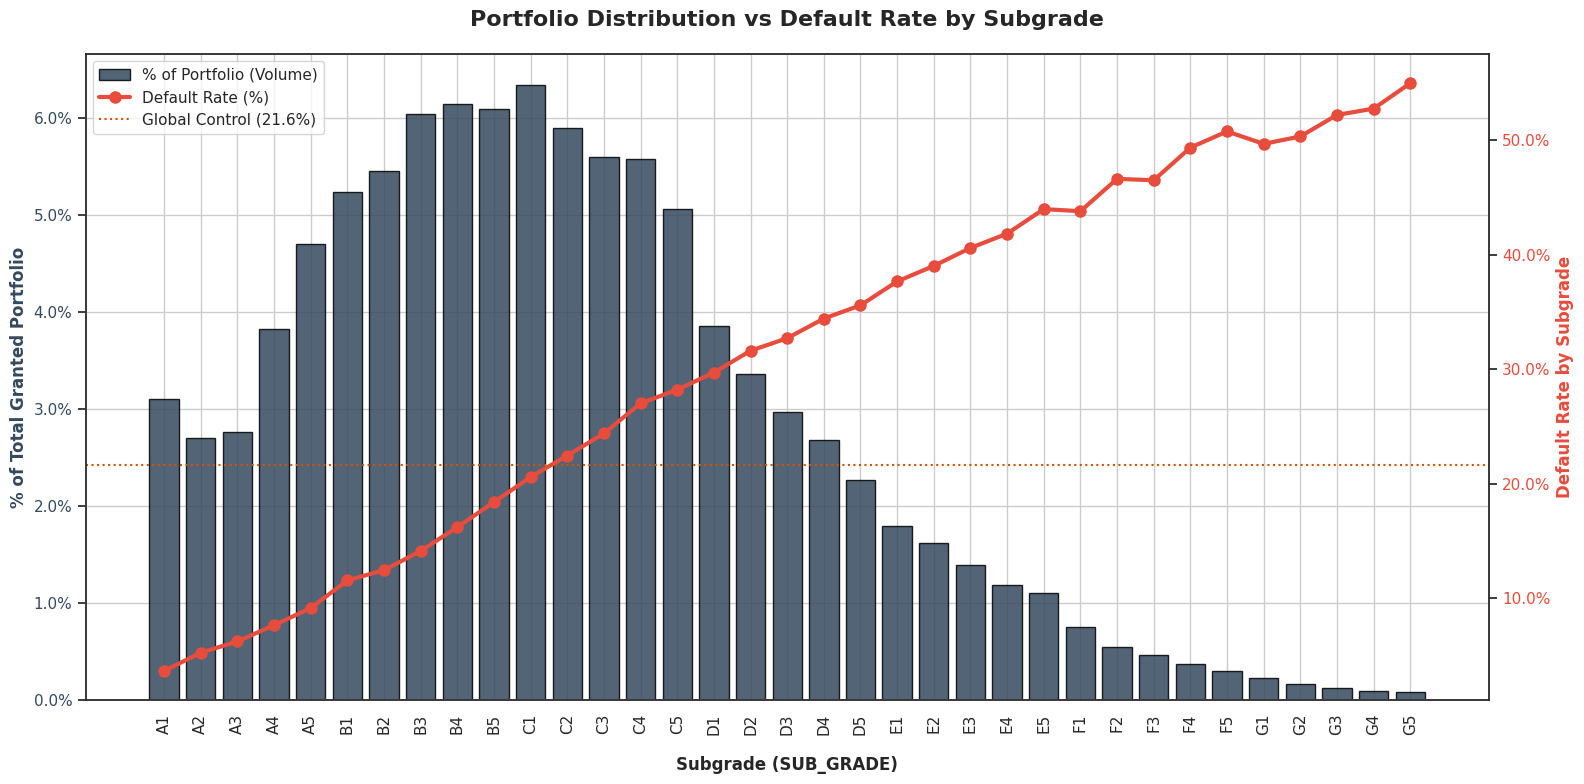


📋 STRATEGIC RISK APPETITE TABLE:
Subgrade % Individual Portfolio % Cumulative Portfolio Default Rate
      A1                  3.11%                  3.11%        3.67%
      A2                  2.70%                  5.81%        5.26%
      A3                  2.77%                  8.58%        6.24%
      A4                  3.83%                 12.41%        7.67%
      A5                  4.70%                 17.11%        9.16%
      B1                  5.24%                 22.35%       11.57%
      B2                  5.45%                 27.80%       12.47%
      B3                  6.04%                 33.85%       14.14%
      B4                  6.15%                 40.00%       16.22%
      B5                  6.10%                 46.10%       18.41%
      C1                  6.35%                 52.45%       20.59%
      C2                  5.90%                 58.35%       22.47%
      C3                  5.60%                 63.95%       24.40%
      C4      

30

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# --- 1. OPTIMIZED DATA LOADING ---
file_path_processed = '/content/drive/MyDrive/Archivo de 1GB - loans/loan_processed.parquet'
TARGET_VAR = 'loan_status'

print("Loading data...")
df_raw = pd.read_parquet(file_path_processed, columns=['sub_grade', TARGET_VAR])

# --- 2. TARGET PREPARATION ---
df_clean = df_raw.dropna(subset=[TARGET_VAR]).copy()
del df_raw
gc.collect()

if df_clean[TARGET_VAR].dtype == 'object' or isinstance(df_clean[TARGET_VAR].dtype, pd.CategoricalDtype):
    status_mapping = {
        'Fully Paid': 0.0, 'Does not meet the credit policy. Status:Fully Paid': 0.0,
        'Charged Off': 1.0, 'Default': 1.0, 'Does not meet the credit policy. Status:Charged Off': 1.0,
        'Late (31-120 days)': 1.0, 'Late (16-30 days)': 1.0
    }
    df_clean['target'] = df_clean[TARGET_VAR].map(status_mapping)
    df_clean = df_clean.dropna(subset=['target'])
else:
    df_clean['target'] = pd.to_numeric(df_clean[TARGET_VAR], errors='coerce')
    df_clean = df_clean.dropna(subset=['target'])

TARGET_VAR_PROCESSED = 'target'

# --- 3. VOLUME AND DEFAULT RATE CALCULATION BY SUBGRADE ---
# Group to calculate loan counts and default rates
res = df_clean.groupby('sub_grade', observed=False).agg(
    total_loans=('target', 'count'),
    default_rate=('target', 'mean')
).reset_index()

# Calculate the % share of each subgrade in the portfolio
total_portfolio = res['total_loans'].sum()
res['portfolio_share'] = (res['total_loans'] / total_portfolio) * 100
res['default_rate_pct'] = res['default_rate'] * 100

# Sort alphabetically to preserve risk hierarchy (A1, A2... G5)
res = res.sort_values(by='sub_grade').reset_index(drop=True)

# Calculate cumulative share to see how much of the portfolio is cut off at each risk tier
res['cumulative_share'] = res['portfolio_share'].cumsum()

# --- 4. DUAL-AXIS PLOT ---
fig, ax1 = plt.subplots(figsize=(16, 8))
sns.set_theme(style="white")

# Left axis (Blue/Slate): % of the Portfolio represented by each subgrade
bar_color = '#34495e'
bars = ax1.bar(res['sub_grade'], res['portfolio_share'], color=bar_color, alpha=0.85, edgecolor='black', label='% of Portfolio (Volume)')
ax1.set_xlabel('Subgrade (SUB_GRADE)', fontsize=12, fontweight='bold', labelpad=15)
ax1.set_ylabel('% of Total Granted Portfolio', color=bar_color, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=bar_color)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax1.set_xticklabels(res['sub_grade'], rotation=90)

# Right axis (Red): Default Rate
line_color = '#e74c3c'
line = ax2 = ax1.twinx()
ax2.plot(res['sub_grade'], res['default_rate_pct'], color=line_color, marker='o', linewidth=3, markersize=8, label='Default Rate (%)')
ax2.set_ylabel('Default Rate by Subgrade', color=line_color, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=line_color)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

# Add global default control line
global_rate_pct = df_clean[TARGET_VAR_PROCESSED].mean() * 100
ax2.axhline(global_rate_pct, color='#d35400', linestyle=':', linewidth=1.5, label=f'Global Control ({global_rate_pct:.1f}%)')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=11, frameon=True)

plt.title('Portfolio Distribution vs Default Rate by Subgrade', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# --- 5. SUMMARY TABLE FOR STRATEGIC DECISION MAKING ---
print("\n📋 STRATEGIC RISK APPETITE TABLE:")
strategic_table = res[['sub_grade', 'portfolio_share', 'cumulative_share', 'default_rate_pct']].copy()
strategic_table.columns = ['Subgrade', '% Individual Portfolio', '% Cumulative Portfolio', 'Default Rate']
print(strategic_table.to_string(index=False, formatters={
    '% Individual Portfolio': '{:.2f}%'.format,
    '% Cumulative Portfolio': '{:.2f}%'.format,
    'Default Rate': '{:.2f}%'.format
}))

# Clean up memory
del df_clean, res
gc.collect()

Loading optimized dataset...
Training set size: 400,000
Test set size: 100,000
Training the LightGBM classifier...

MODEL PERFORMANCE (ROC-AUC): 0.7057

📋 Classification Report (Threshold = 25%):
                    precision    recall  f1-score   support

       Approve (0)       0.86      0.77      0.81     79887
Reject/Default (1)       0.35      0.51      0.42     20113

          accuracy                           0.71    100000
         macro avg       0.61      0.64      0.61    100000
      weighted avg       0.76      0.71      0.73    100000



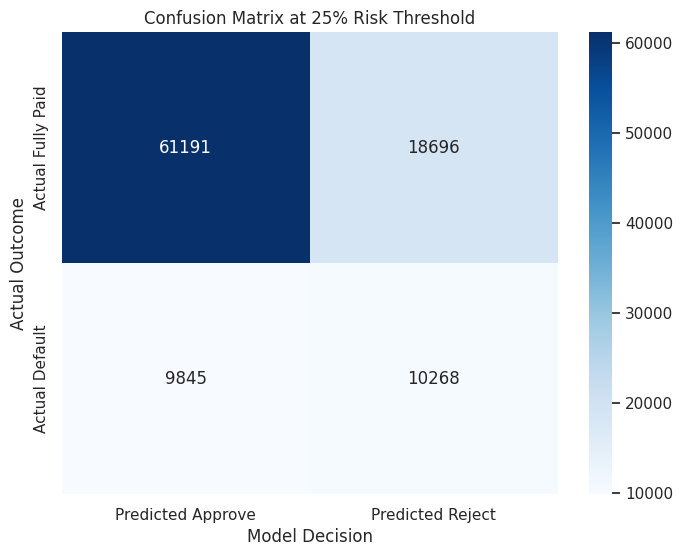

In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# --- 1. CONFIGURATION & DATA LOADING ---
file_path_processed = '/content/drive/MyDrive/Archivo de 1GB - loans/loan_processed.parquet'
target_col = 'loan_status'

features = [
    'funded_amnt', 'term', 'installment', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'mths_since_last_delinq', 'pub_rec',
    'revol_bal', 'revol_util', 'application_type', 'dti_joint',
    'verification_status_joint', 'mths_since_last_major_derog', 'il_util'
]

columns_to_load = features + [target_col]

print("Loading optimized dataset...")
df = pd.read_parquet(file_path_processed, columns=columns_to_load)

# --- 2. TARGET MAPPING & CLEANING ---
df = df.dropna(subset=[target_col])
status_mapping = {
    'Fully Paid': 0,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Charged Off': 1
}
df[target_col] = df[target_col].map(status_mapping)
df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].astype('int8')

# Downsample to 500k rows for memory safety and fast training
if len(df) > 500000:
    df = df.sample(n=500000, random_state=42)

X = df[features].copy()
y = df[target_col].copy()
del df
gc.collect()

# --- 3. DTYPE CONVERSION & CATEGORICAL PROCESSING ---
for col in X.select_dtypes(include=['float64']).columns:
    X[col] = X[col].astype('float32')
for col in X.select_dtypes(include=['int64']).columns:
    X[col] = X[col].astype('int32')

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    X[col] = X[col].astype('category')

# --- 4. TRAIN-TEST SPLIT ---
# Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size: {X_test.shape[0]:,}")

# --- 5. LIGHTGBM TRAINING ---
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=categorical_cols)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'verbose': -1,
    'seed': 42
}

print("Training the LightGBM classifier...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=150,
    valid_sets=[test_data]
)

# --- 6. PREDICTING AND APPLYING AN UNDERWRITING THRESHOLD ---
# Predict raw probabilities (values between 0 and 1)
y_probs = model.predict(X_test)

# Define our risk tolerance (e.g., Reject if the predicted probability of default is >= 25%)
risk_threshold = 0.25
y_pred = (y_probs >= risk_threshold).astype(int)

# --- 7. PERFORMANCE EVALUATION ---
auc_score = roc_auc_score(y_test, y_probs)
print("\n" + "="*40)
print(f"MODEL PERFORMANCE (ROC-AUC): {auc_score:.4f}")
print("="*40)

print("\n📋 Classification Report (Threshold = 25%):")
print(classification_report(y_test, y_pred, target_names=['Approve (0)', 'Reject/Default (1)']))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Approve', 'Predicted Reject'],
            yticklabels=['Actual Fully Paid', 'Actual Default'])
plt.title(f'Confusion Matrix at {risk_threshold*100:.0f}% Risk Threshold')
plt.ylabel('Actual Outcome')
plt.xlabel('Model Decision')
plt.show()